# LSN Exercises 09
## Traveling salesman problem with genetic algorithm


Gabriele Borroni (14768A)


---

## The traveling salesman problem

The traveling salesman problem (TSP) consists in a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

Consider now the ordered sequence of cities, $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, which goes from city 1 to the $n^{th}$ city. The best path is the one that minimizes the following loss function:

$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$

TSP fits in the class of **NP-hard** optimization problems: one one hand, given a path it is straightforward to compute L(x) to judge its efficiency; on the other hand, finding the best path among all the possible ones becomes rapidly difficult as the number of cities grows. No existing algortihm can solve this problem in a polinomial time: its complexity scales exponentially with the number of cities involved. 

This challenge lead to the developement of **metaheuristic algorithms** such as the genetic algorithm, which has been used in this exercise.

## The genetic algorithm

This algorithm is, of course, inspired by evolutional biology. The idea is to organize the cities as **genes** in a **chromosome**, that will contain a possible path. all the chromosomes are then put in a **population**, which will store all the current paths. The TSP constraints are that the salseman must never visit the same city twice, and at the end of the journey he must turn back to the first city. To accont for this, **the first gene (the starting city) in each chromosome has been fixed** and the passage from the last city to the first one has been included only in the loss calculation. Check_boundary() method checks if this constraints are satisfied every time a chromosome is modified or created during the optimization.

The code is organized in two main classes: the chromosome class and the GA one. The chromosome class has an arma::vector as main private variable, and implements all the methods necessary to modify genes such as swap, get/set and check_boundary. The GA class is the one that actually implements the genethic algorithm, by working on a private data-member population, an arma::vec of Chromosome objects.

The population is generated in the GA class constructor by creating a template chromosome containing all the cities sorted in ascending order ($[1,2,3, \dots, N]$), and then each new chromosome in the population is generated by randomly swapping 2 genes N times in the template (always without choosing the first gene). This method automatically grants that there will not be chromosomes with duplicated genes (so that every city is visited only once).

### Mutation operators

As in biology, the minimum (the best population) is reached by reproduction (crossover) and random genethic mutations. In the code 4 of them have been implemented:

1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$.
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

The reproduction of population is modeled by the **crossover operator**:
given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

### Unfair roulette selection and elitism
To create a new population which is better than the previous in an efficient way, fathers and mothers can't be chosen completely blindly. Evolution says that the best individuals will reproduce more, and this has been implemented by using **unfair roulette selection operator**: the individuals in the population are sorted by fitness ( by increasing order of loss) and then the ones with the smallest loss are picked up with higher probability.

The Selection() method, after calling sort_by_fitness(), picks the individuals with:
$$j= int(M \times r^p)+1$$
 where $r$ is a uniform random number $r\in[0,1)$ and $p=2$ shifts the samples in the first region of the population vector (which contain the best individuals).

**elitism** gives the possibility tho chose to copy N among the best indiviuals into the next population. This, if N is tuned properly, can lead to a faster convergence. In this case N=1 was sufficient: increasing furtherly N would reduce the variability and the algorithm becomes more susceptible to get stuck in local minimums.

### The core: Evolve() method

The Evolve() method in the class GA puts all the mentioned functions together in order to generate the new population. This method is the engine of the genethic algorithm:
1. Sort the actual population by fitness with sort_by_fitness() method and allocate a new population (vector<chromosome>new_population). Put the best individual of the currento population into the new one (elitism with N=1).

2. Use the selection() method N times to generate N sons in the new population by applying random mutations with probabilities: 
$$
\begin{align*}
P_{\text{pair}}      &= 0.12 \\
P_{\text{shift}}     &= 0.20 \\
P_{\text{perm}}      &= 0.12 \\
P_{\text{invert}}    &= 0.15 \\
P_{\text{crossover}} &= 0.50
\end{align*}
$$

3. Replace the current population with the new one.

Having the code organized like so, the main TSP.cpp simply loads the cities positions and calculates all the distances between them, storing them in a matrix D. Then it allocates a GA object and runs the optimization by calling the Evolve() method N_generation times. Other methods such as Pick_best() are finally used to output the results shown below.



Below the plots show the best path for **34 cities randomly placed on a circumference** found with the GA optimization. This case was used as benchmark to check if the code is working, because of course in this case the best path is the one that follows the circumference.




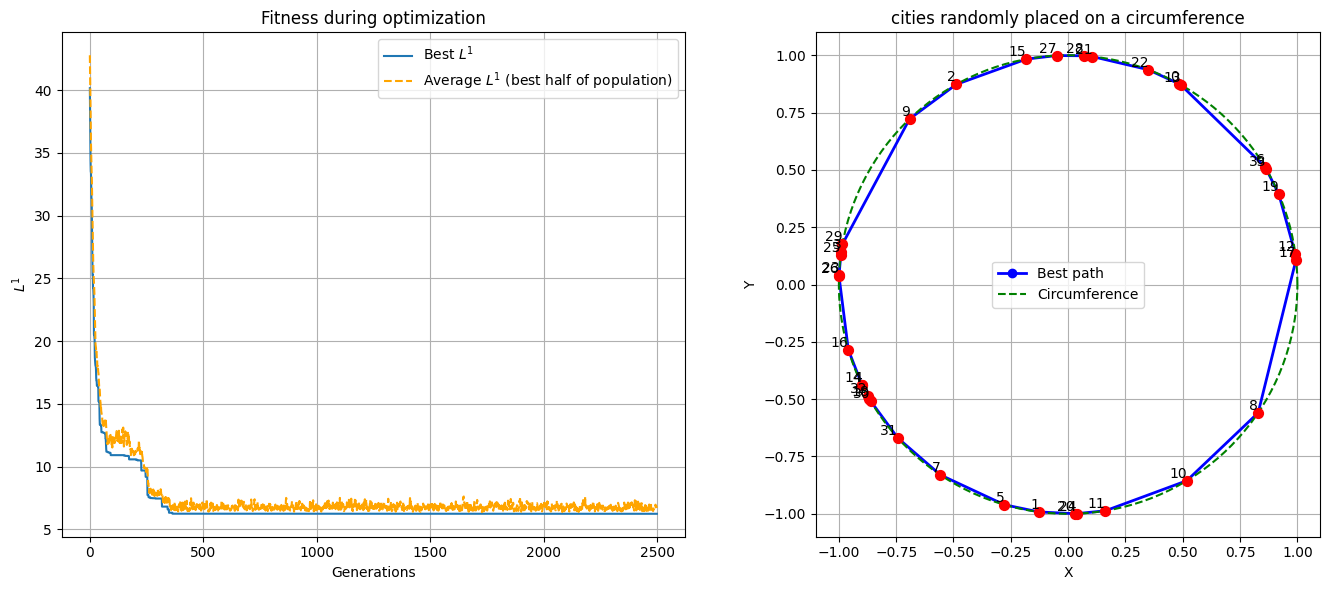

best final loss=6.23883


In [15]:
import matplotlib.pyplot as plt
import numpy as np

#load cities distribution
data = np.loadtxt("OUTPUT/cities_mapC.dat")
x_c = data [: , 1]
y_c = data [: , 2]
labels_c = data[:, 0].astype(int)
#load best path
best_path = np.loadtxt("OUTPUT/best_pathC.dat", dtype=int)
x_path = x_c[best_path]
y_path = y_c[best_path]
#add return home
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])


#fitness during optimization data
stats = np.loadtxt("OUTPUT/besthalflossC.dat")
statsbest = np.loadtxt("OUTPUT/Best_lossC.dat")
generations = stats[:, 0]
best_fit = statsbest[:, 1]
avg_fit = stats[:, 1]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(generations, best_fit, label=r'Best $L^1$')
ax1.plot(generations, avg_fit, label=r'Average $L^1$ (best half of population)', color='orange', linestyle='--')
ax1.set_xlabel("Generations")
ax1.set_ylabel(r"$L^1$")
ax1.set_title("Fitness during optimization")
ax1.grid(True)
ax1.legend()

#plot best path
ax2.plot(x_path, y_path, 'b-o', linewidth=2, markersize=6, label='Best path')
ax2.scatter(x_c, y_c, color='red', s=50, zorder=3)
for i, label in enumerate(labels_c):
    ax2.text(x_c[i], y_c[i], str(label), fontsize=10, ha='right', va='bottom')

#circle
theta = np.linspace(0, 2 * np.pi, 300)
r = 1.0 
xc = r * np.cos(theta)
yc= r* np.sin(theta)
ax2.plot(xc, yc, 'g--', label='Circumference')
ax2.set_aspect('equal')
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("cities randomly placed on a circumference")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
print(f"best final loss={best_fit[-1]}")

---

In the second part, the GA has been used to find the best path for 34 cities randomly placed on a square. 

Same plots than before show the results below.

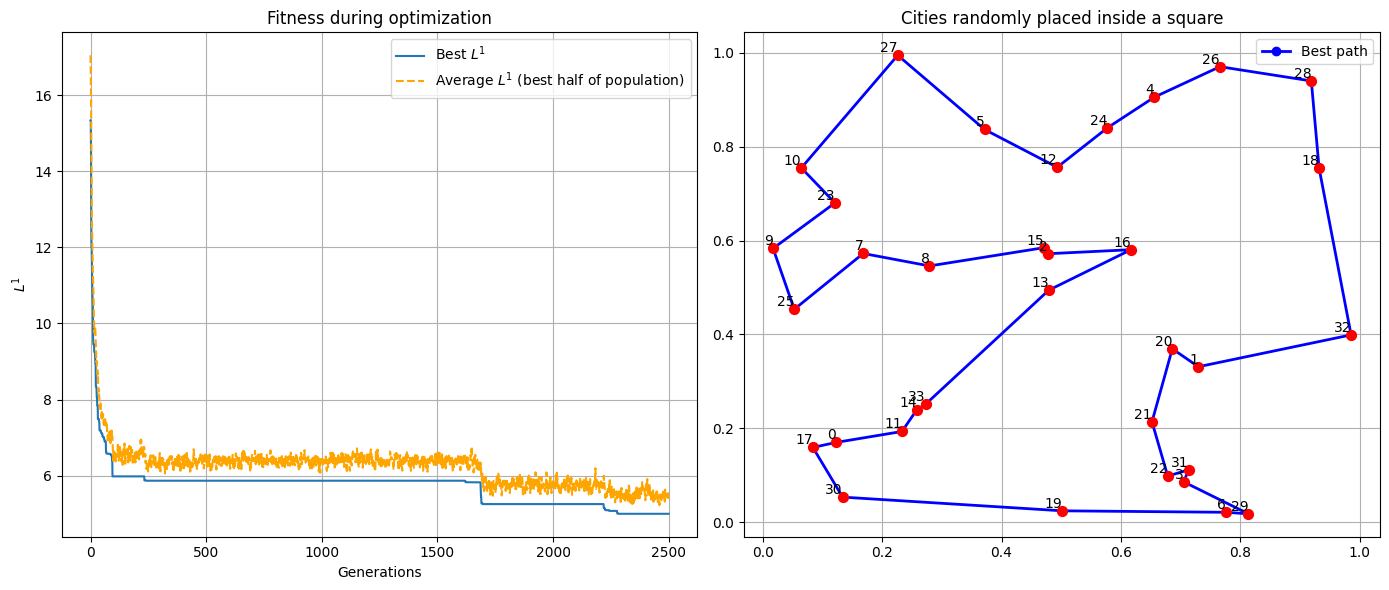

best final loss=4.99658


In [14]:
import matplotlib.pyplot as plt
import numpy as np

#load cities distribution
data = np.loadtxt("OUTPUT/cities_map.dat")
x_c = data [: , 1]
y_c = data [: , 2]
labels_c = data[:, 0].astype(int)
#load best path
best_path = np.loadtxt("OUTPUT/best_path.dat", dtype=int)
x_path = x_c[best_path]
y_path = y_c[best_path]
#add return home
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])


#fitness during optimization data
stats = np.loadtxt("OUTPUT/besthalfloss.dat")
statsbest = np.loadtxt("OUTPUT/Best_loss.dat")
generations = stats[:, 0]
best_fit = statsbest[:, 1]
avg_fit = stats[:, 1]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(generations, best_fit, label=r'Best $L^1$')
ax1.plot(generations, avg_fit, label=r'Average $L^1$ (best half of population)', color='orange', linestyle='--')
ax1.set_xlabel("Generations")
ax1.set_ylabel(r"$L^1$")
ax1.set_title("Fitness during optimization")
ax1.grid(True)
ax1.legend()

#plot best path
ax2.plot(x_path, y_path, 'b-o', linewidth=2, markersize=6, label='Best path')
ax2.scatter(x_c, y_c, color='red', s=50, zorder=3)
for i, label in enumerate(labels_c):
    ax2.text(x_c[i], y_c[i], str(label), fontsize=10, ha='right', va='bottom')
ax2.grid(True)
ax2.legend()
ax2.set_title("Cities randomly placed inside a square")

plt.tight_layout()
plt.show()
print(f"best final loss={best_fit[-1]}")


# BONUS: Ant colony optimization (ACO)

There is a wide class of metaheuristic algorithms developed to solve the TSP, and another biology-inspired interesting one is the **ant colony optimization algorithm**, which is of course inspired by how ants search food.

Ants communicate between them by releasing chemical **pheromones** on the paths they travel .Other ants are more likely to follow paths with stronger pheromone trails, which are the ones that lead to food, reinforcing good paths and enabling collective optimization.

The algorithm models an ant colony, where every ant is a random walker. Starting from a city i, an ant chooses its next city j with probability:
$$
P_{ij} = \frac{\left[\tau_{ij}\right]^\beta \left[\eta_{ij}\right]^\alpha}
{\sum\limits_{k \in \text{unvisited}} \left[\tau_{ik}\right]^\beta \left[\eta_{ik}\right]^\alpha}
$$

Where $\tau_{ij}$ is the **pheromone intensity on edge (i,j)** and $\eta_{ij} = \frac{1}{d_{ij}}$ is the **visibility** (inverse of distance). The exponents $\alpha$ and $\beta$ tune the importance for each ant to follow the most visible or the most chemically marked path respectively.

At the end of its walk, each ant releases pheromones on their path. The less their loss, the more pheromones they release.

$$
\tau_{ij} \leftarrow \tau_{ij} + \sum_{k=1}^{m} \Delta \tau_{ij}^{(k)}
$$

Where

 $$
 \Delta \tau_{ij}^{(k)} =
\begin{cases}
\frac{Q}{L_k}, & \text{if ant k crossed (i,j) arc }\\
0, & \text{else}
\end{cases}
$$

as feromones are chemical substances, they can **evaporate**. To reduce the system memory,aAt each step, the feromons are reduced by:

$$
\tau_{ij} \leftarrow (1 - \rho)\tau_{ij}
$$


The code is again organized in a class, in a similar way to the genetic algrithm.


The **Ant class** contains, above get/set methods, the Walk one, which performs the walk in the cited manner. 

In particular, at each step, the next city is chosen like so:

1. Calculate the cumulative probability over the unvisited cities
$$
C_j = \sum_{k=0}^{j} P_{ik}
\quad \text{per } j = 0, 1, \dots, n-1
$$

2. Throw a uniform random number r

3. if, for some $j\in Unvisited$
$$

C_{j-1} \leq r \leq C_J

$$
then Unvisited(j) will be the next visited city.

The **colony class** builds a vector of Ant objects, and with the Search() method it makes them walk, than the feromones deposit is obtained with the Update_feromones method, which simply applies the formula cited above.

---

## Results

The ACO algorithm has been applied in the same context as the genetic one, choosing Nants=Nchromosomes=200. In both cases, the ACO algorithm is incredibly faster than the genetic one, and it's able to find a minimum within the first 5 iterations.






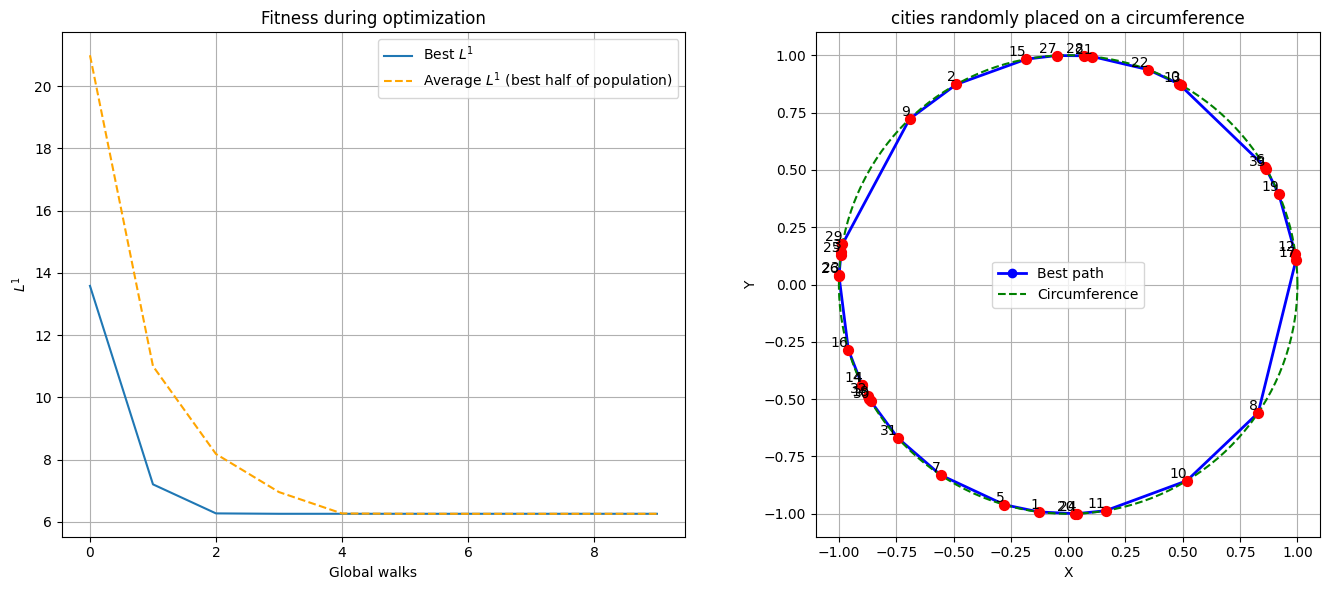

best final loss=6.25848


In [13]:

#load cities distribution
data = np.loadtxt("ACO/OUTPUT/cities_mapC.dat")
x_c = data [: , 1]
y_c = data [: , 2]
labels_c = data[:, 0].astype(int)
#load best path
best_path = np.loadtxt("ACO/OUTPUT/best_pathC.dat", dtype=int)
x_path = x_c[best_path]
y_path = y_c[best_path]
#add return home
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])


#fitness during optimization data
stats = np.loadtxt("ACO/OUTPUT/besthalflossC.dat")
statsbest = np.loadtxt("ACO/OUTPUT/best_lossC.dat")
generations = np.arange(len(stats))
best_fit = statsbest
avg_fit = stats


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(generations, best_fit, label=r'Best $L^1$')
ax1.plot(generations, avg_fit, label=r'Average $L^1$ (best half of population)', color='orange', linestyle='--')
ax1.set_xlabel("Global walks")
ax1.set_ylabel(r"$L^1$")
ax1.set_title("Fitness during optimization")
ax1.grid(True)
ax1.legend()

#plot best path
ax2.plot(x_path, y_path, 'b-o', linewidth=2, markersize=6, label='Best path')
ax2.scatter(x_c, y_c, color='red', s=50, zorder=3)
for i, label in enumerate(labels_c):
    ax2.text(x_c[i], y_c[i], str(label), fontsize=10, ha='right', va='bottom')

#circle
theta = np.linspace(0, 2 * np.pi, 300)
r = 1.0 
xc = r * np.cos(theta)
yc= r* np.sin(theta)
ax2.plot(xc, yc, 'g--', label='Circumference')
ax2.set_aspect('equal')
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("cities randomly placed on a circumference")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
print(f"best final loss={best_fit[-1]}")


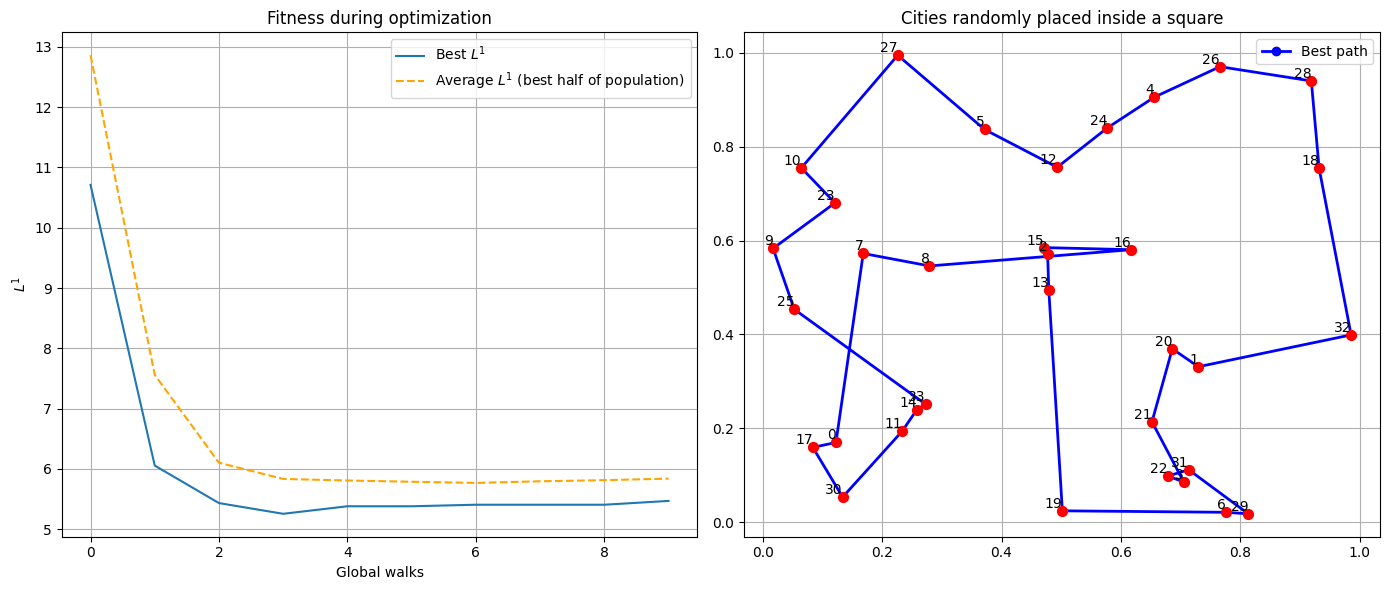

best final loss=5.47007


In [12]:
import matplotlib.pyplot as plt
import numpy as np

#load cities distribution
data = np.loadtxt("ACO/OUTPUT/cities_map.dat")
x_c = data [: , 1]
y_c = data [: , 2]
labels_c = data[:, 0].astype(int)
#load best path
best_path = np.loadtxt("ACO/OUTPUT/best_path.dat", dtype=int)
x_path = x_c[best_path]
y_path = y_c[best_path]
#add return home
x_path = np.append(x_path, x_path[0])
y_path = np.append(y_path, y_path[0])


#fitness during optimization data
stats = np.loadtxt("ACO/OUTPUT/besthalfloss.dat")
statsbest = np.loadtxt("ACO/OUTPUT/Best_loss.dat")
generations = np.arange(len(stats))
best_fit = statsbest
avg_fit = stats


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(generations, best_fit, label=r'Best $L^1$')
ax1.plot(generations, avg_fit, label=r'Average $L^1$ (best half of population)', color='orange', linestyle='--')
ax1.set_xlabel("Global walks")
ax1.set_ylabel(r"$L^1$")
ax1.set_title("Fitness during optimization")
ax1.grid(True)
ax1.legend()

#plot best path
ax2.plot(x_path, y_path, 'b-o', linewidth=2, markersize=6, label='Best path')
ax2.scatter(x_c, y_c, color='red', s=50, zorder=3)
for i, label in enumerate(labels_c):
    ax2.text(x_c[i], y_c[i], str(label), fontsize=10, ha='right', va='bottom')
ax2.grid(True)
ax2.legend()
ax2.set_title("Cities randomly placed inside a square")

plt.tight_layout()
plt.show()
print(f"best final loss={best_fit[-1]}")


credits: https://web2.qatar.cmu.edu/~gdicaro/15382/additional/aco-book.pdf